In [1]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from LSTM import LSTM

In [3]:
csv_path = os.path.join('dataset', 'data_final.csv')

dataset = pd.read_csv(
    csv_path,
    index_col='Date',
    parse_dates=['Date']
)

dataset.head()

,전력량,Weekend,Vacation,time_sin,time_cos,day_sin,day_cos
Date,,,,,,,
2021-01-01 00:15:00,62.0,0.0,0.0,0.065403,0.997859,-0.433884,-0.900969
2021-01-01 00:30:00,61.0,0.0,0.0,0.130526,0.991445,-0.433884,-0.900969
2021-01-01 00:45:00,61.0,0.0,0.0,0.195090,0.980785,-0.433884,-0.900969
2021-01-01 01:00:00,61.0,0.0,0.0,0.258819,0.965926,-0.433884,-0.900969
2021-01-01 01:15:00,96.0,0.0,0.0,0.321439,0.946930,-0.433884,-0.900969


In [4]:
split1 = int(len(dataset) * 0.6)
split2 = int(len(dataset) * 0.8)

print(f'검증 셋 기준 날짜 : {dataset.index[split1]}')
print(f'테스트 셋 기준 날짜 : {dataset.index[split2]}')

검증 셋 기준 날짜 : 2021-06-04 05:00:00
테스트 셋 기준 날짜 : 2021-07-25 14:30:00


In [5]:
train = dataset.loc[:'2021-06-04 23:45']

valid = dataset.loc[
    '2021-06-05 00:00':'2021-07-25 23:45'
]

test = dataset.loc['2021-07-26 00:00':]

print(f'훈련 셋 크기 : {len(train)}, 검증 셋 크기 : {len(valid)}, 테스트 셋 크기 : {len(test)}')

훈련 셋 크기 : 14879, 검증 셋 크기 : 4896, 테스트 셋 크기 : 4897


In [ ]:
scaler = StandardScaler()

cols = train.columns
idx_train = train.index
idx_valid = valid.index
idx_test = test.index

train_scaled = pd.DataFrame(scaler.fit_transform(train),
                            columns=cols,
                            index=idx_train)
valid_scaled = pd.DataFrame(scaler.transform(valid),
                            columns=cols,
                            index=idx_valid)
test_scaled = pd.DataFrame(scaler.transform(test),
                            columns=cols,
                            index=idx_test)

,전력량,Weekend,Vacation,time_sin,time_cos,day_sin,day_cos
Date,,,,,,,
2021-01-01 00:15:00,-0.530753,-0.406727,0.0,0.092491,1.411328,-0.610908,-1.263556
2021-01-01 00:30:00,-0.548494,-0.406727,0.0,0.184586,1.402257,-0.610908,-1.263556
2021-01-01 00:45:00,-0.548494,-0.406727,0.0,0.275890,1.387182,-0.610908,-1.263556
2021-01-01 01:00:00,-0.548494,-0.406727,0.0,0.366013,1.366166,-0.610908,-1.263556
2021-01-01 01:15:00,0.072452,-0.406727,0.0,0.454569,1.339301,-0.610908,-1.263556


In [7]:
def make_sequences(data, window_size = 96):
    
    X = []
    y = []

    features = data.columns
    target = '전력량'

    feature_data = data[features].values
    target_data = data[target].values

    for i in range(window_size, len(data)):
        
        X.append(
            feature_data[i-window_size:i]
        )
        
        y.append(
            target_data[i]
        )

    return np.array(X), np.array(y)

In [8]:
X_train, y_train = make_sequences(train_scaled, window_size=96)
X_valid, y_valid = make_sequences(valid, window_size=96)
X_test, y_test = make_sequences(test, window_size=96)

print(f'훈련 셋 feature : {X_train.shape}, target : {y_train.shape}')
print(f'검증 셋 feature : {X_valid.shape}, target : {y_valid.shape}')
print(f'테스트 셋 feature : {X_test.shape}, target : {y_test.shape}')

훈련 셋 feature : (14783, 96, 7), target : (14783,)
검증 셋 feature : (4800, 96, 7), target : (4800,)
테스트 셋 feature : (4801, 96, 7), target : (4801,)


In [9]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_valid = torch.tensor(X_valid, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [10]:
train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = LSTM(
    input_size=X_train.size(2),
    hidden_size=32,
    num_layers=2,
).to(device)

In [12]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epoch = 100

In [ ]:
model.train()

loss_graph = []
n = len(train_loader)

for epoch in range(num_epoch):
    running_loss = 0.0

    for x, y in train_loader:

        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    loss_graph.append(running_loss / n)

    if epoch % 10 == 0:
        print(f'[epoch: {epoch}] loss : {running_loss :.4f}')

[epoch: 0] loss : 21.7733


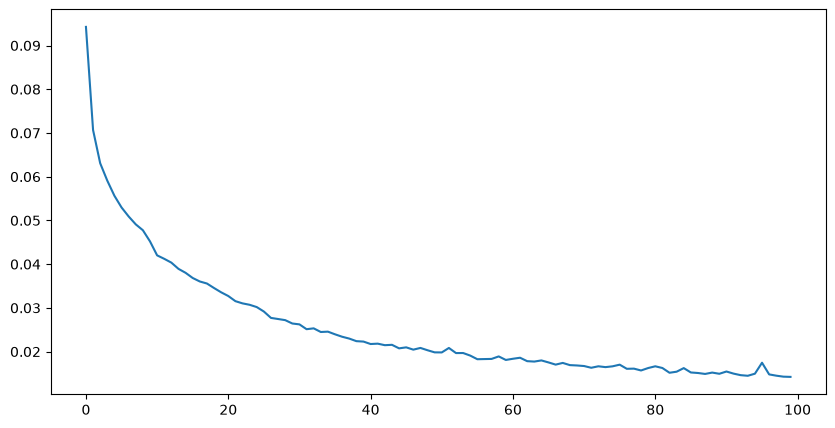

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(loss_graph)
plt.show()